# quick check of isaura/beersheba data

In [1]:
import sys
sys.path.append("/home/e78368jw/Documents/NEXT_CODE/")
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import FOM_functions as FOM_func
import functions_HE as func

In [7]:
#data_path = 'data/track_isaura_250326_6.h5'
data_path = 'data/track_isaura_250326_6.h5'
#data_path = 'data/track_isaura_250326_9.h5'
x = pd.read_hdf(data_path, key = 'Tracking/Tracks')
#x = pd.read_hdf('data/track_isaura_250326_12.h5', key = 'Tracking/Tracks')
#x = pd.read_hdf('data/track_isaura_250326_9.h5', key = 'Tracking/Tracks')
display(x)

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,150400000,0,1.591420,258.883195,1694,56094,2,29.875,15.575,189.205099,...,308.258120,155.694428,65.957611,190.669118,0.443614,0.084150,0.000000,5.862069,5.736842,5.814343
1,150400000,1,0.000122,14.064216,6,81,2,132.875,86.575,275.852694,...,275.852694,141.923595,91.383340,275.852694,0.000122,0.000122,0.000122,5.862069,5.736842,5.814343
2,150400001,0,1.616743,347.298254,1746,59184,2,267.875,-220.425,150.983538,...,293.204940,331.480168,-112.958546,171.089864,0.151653,0.051409,0.000000,5.900000,5.933333,5.990131
3,150400001,1,0.000615,14.300797,7,106,2,364.875,-84.425,282.697256,...,282.697256,367.648010,-79.534440,282.697256,0.000615,0.000615,0.000615,5.900000,5.933333,5.990131
4,150400002,0,1.154707,237.987100,821,28040,2,114.875,261.575,235.436980,...,243.669490,264.940802,293.631132,350.548278,0.654579,0.071344,0.000000,5.870968,5.789474,5.908348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,612400143,2,0.108107,143.114560,325,7548,4,184.875,-5.425,888.294469,...,901.242338,232.875000,24.575000,961.308131,0.030843,0.015488,0.000000,5.848485,5.931034,5.938798
296,612400143,3,0.009699,60.207415,59,1097,4,224.875,41.575,857.042002,...,863.969938,243.326955,63.044669,866.644039,0.009314,0.008648,0.008264,5.848485,5.931034,5.938798
297,612400144,0,1.601712,223.466983,1807,69453,1,-248.125,-264.425,1039.094505,...,1101.568032,-128.672578,-131.826266,1042.444223,0.416004,0.139679,0.000000,5.840000,5.892857,5.994184
298,612400145,0,1.605540,131.119267,981,40548,1,-333.125,-63.425,511.938341,...,582.684688,-293.446062,22.225152,537.763998,0.687346,0.397323,0.000000,6.000000,5.947368,5.750852


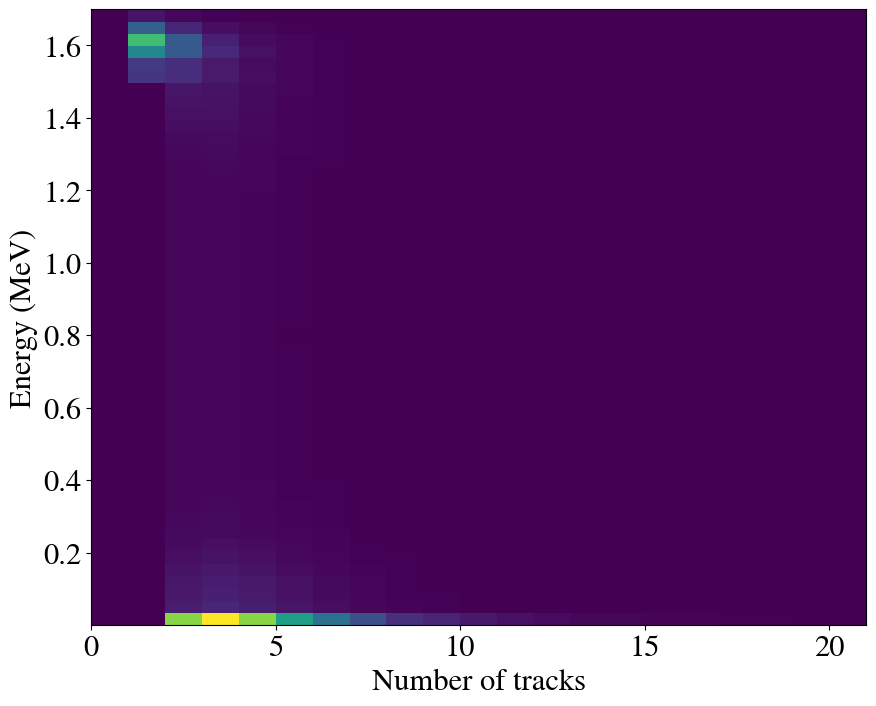

In [8]:
plt.hist2d(x.numb_of_tracks, x.energy, bins = (np.arange(0, x.numb_of_tracks.nunique() + 1), 50))
plt.xlabel('Number of tracks')
plt.ylabel('Energy (MeV)')
plt.show()

Number of 1-tracks after ROI cuts: 96888
Number of events post fiducial: 28027


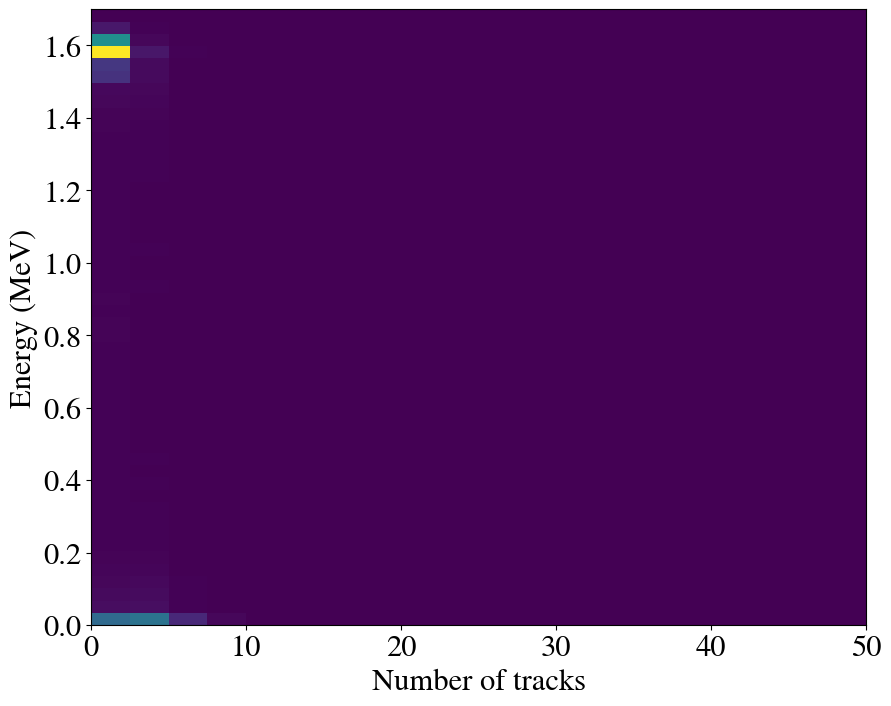

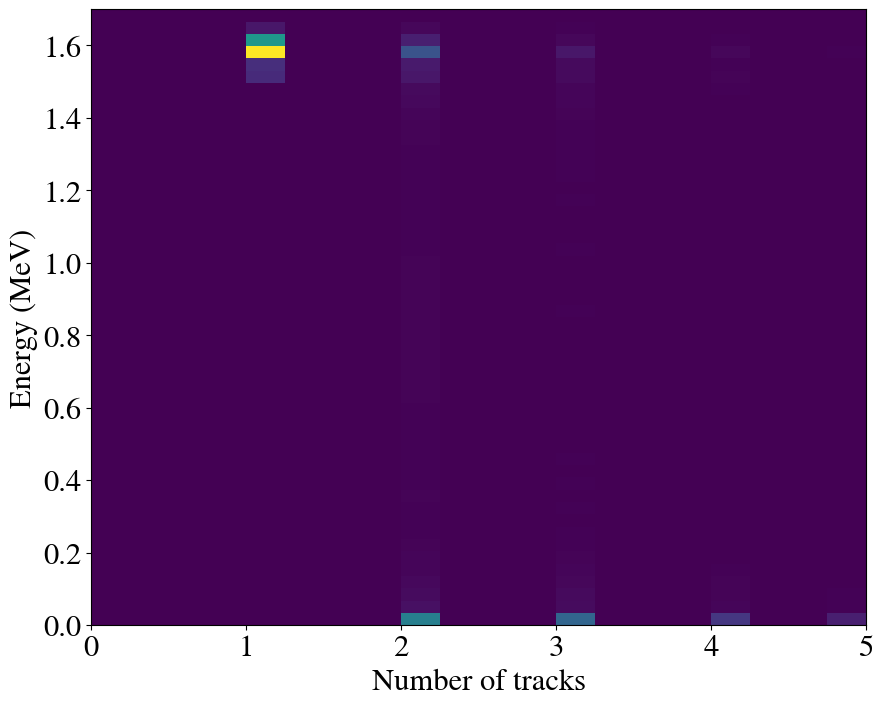

Number of 1-tracks after ROI cuts: 96888
Number of events post fiducial: 28027
Number of 1-tracks after ROI & 1-track cuts: 17889


In [57]:
lower_E = 1.5 
upper_E = 1.7
r_lim   = 300
lower_z = 20
upper_z = 1170   
print(f'Number of 1-tracks after ROI cuts: {x[x.numb_of_tracks == 1].event.nunique()}')

fid_tdst = func.fiducial_track_cut_2(x, r_lim = r_lim, lower_z = lower_z, upper_z = upper_z)
print(f"Number of events post fiducial: {fid_tdst.event.nunique()}")
    
# plot the number of tracks against energy
plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 50], [0, 1.7]))
plt.xlabel('Number of tracks')
plt.ylabel('Energy (MeV)')
plt.show()

# plot the number of tracks against energy
plt.hist2d(fid_tdst.numb_of_tracks, fid_tdst.energy, bins = (20, 50), range = ([0, 5], [0, 1.7]))
plt.xlabel('Number of tracks')
plt.ylabel('Energy (MeV)')
plt.show()


print(f'Number of 1-tracks after ROI cuts: {x[x.numb_of_tracks == 1].event.nunique()}')
print(f'Number of events post fiducial: {fid_tdst.event.nunique()}')
print(f'Number of 1-tracks after ROI & 1-track cuts: {fid_tdst[fid_tdst.numb_of_tracks == 1].event.nunique()}')



# apply all cuts

In [58]:
fid   = func.fiducial_track_cut_2(x, lower_z = lower_z, upper_z = upper_z, r_lim = r_lim)
one_t = func.one_track_cuts(fid)
ovlp  = func.overlapping_cuts(one_t)
roi   = func.energy_cuts(ovlp, lower_e = lower_E, upper_e = upper_E)

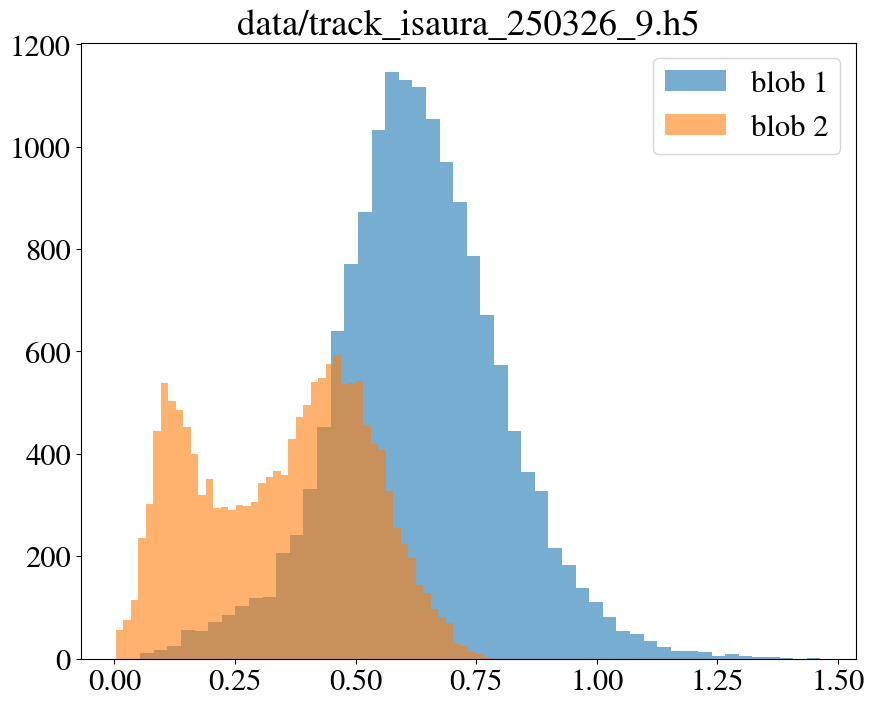

In [59]:
plt.hist(roi.eblob1, bins = 50, label = 'blob 1', alpha = 0.6)
plt.hist(roi.eblob2, bins = 50, label = 'blob 2', alpha = 0.6)
plt.title(f'{data_path}')
plt.legend()
plt.show()

In [60]:

positron_data = np.load('../FOM_beersheba_2026/data/positrons_130426.npy')
p_data = pd.DataFrame()
p_data['event_id'] = positron_data
display(p_data)

,event_id
0,111600002
1,111600006
2,111600007
3,111600010
4,111600011
...,...
136975,991300169
136976,991300171
136977,991300172
136978,991300174


ns, nb
[11174, 11174, 11163, 11137, 11119, 11104, 11083, 11060, 11045, 11024, 11006, 10978, 10950, 10902, 10863, 10823, 10753, 10677, 10592, 10511, 10422, 10334, 10215, 10119, 10020, 9906, 9775, 9626, 9491, 9356, 9182, 9021, 8851, 8663, 8466, 8253, 8038, 7845, 7593, 7310, 7037, 6769, 6442, 6103, 5789, 5424, 5076, 4706, 4333, 4002, 3662, 3330, 2988, 2654, 2385, 2106, 1858, 1606, 1385, 1196, 1048, 889]
[4464, 4464, 4458, 4442, 4412, 4370, 4310, 4170, 4043, 3850, 3587, 3323, 2996, 2698, 2426, 2156, 1935, 1707, 1542, 1388, 1276, 1146, 1044, 952, 850, 792, 738, 681, 639, 589, 550, 509, 465, 435, 400, 381, 345, 322, 301, 279, 261, 241, 217, 201, 187, 174, 162, 144, 134, 126, 111, 103, 98, 89, 81, 74, 67, 54, 46, 38, 34, 32]
FOM values:
[1.         0.99968763 0.99915386 1.00092469 1.00436637 1.00942051
 1.02409566 1.03864534 1.0623369  1.09879645 1.13870567 1.19618029
 1.25498528 1.31873583 1.39372377 1.46164729 1.5452043  1.6128323
 1.68695201 1.74453287 1.82528033 1.89034707 1.96097722 2.05

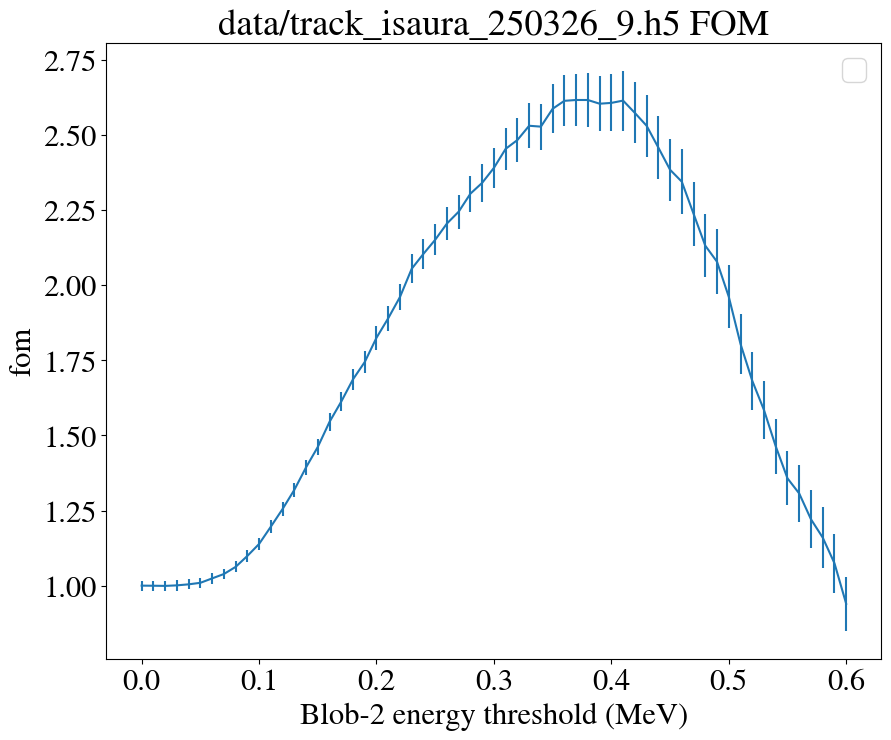

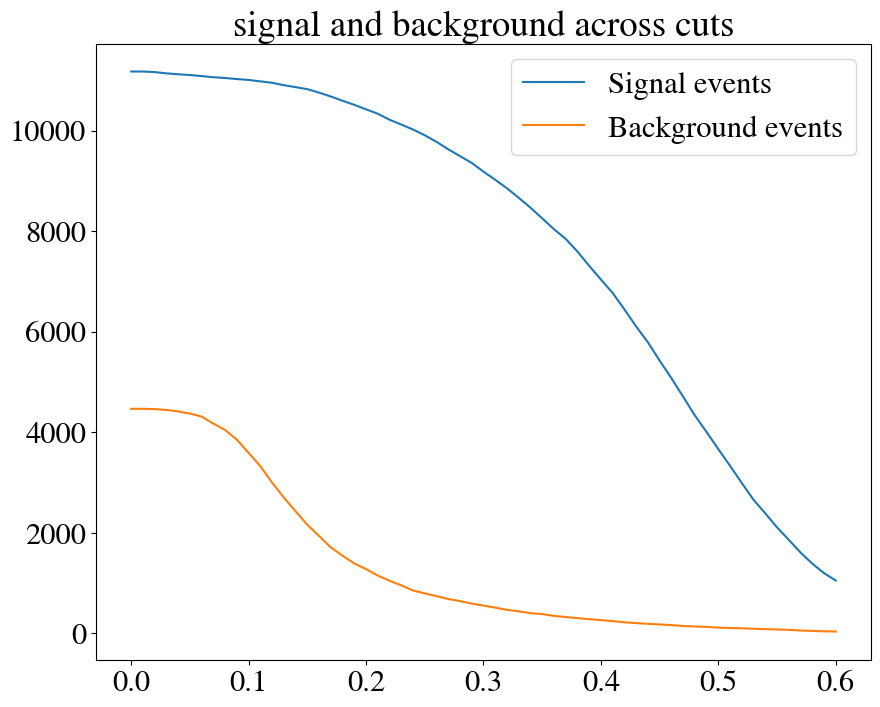

In [61]:
# number of events that are positrons
cut_list = np.linspace(0, 0.6, 61)
ecut_positron_df = roi[roi['event'].isin(positron_data)]
ecut_no_positron_df = roi[~roi['event'].isin(positron_data)]
fom = FOM_func.true_fom_calc(ecut_positron_df, ecut_no_positron_df, cut_list)
# sanitise
ns = fom[2]
nb = fom[3]
fom_erro = np.nan_to_num(fom[1])
fom = np.nan_to_num(fom[0])

print("ns, nb")
print(ns)
print(nb)
    

print("FOM values:")
print(fom)
print("Errors")
print(fom_erro)

# remove stupid values based on low statistics
fom[fom > 10] = 0
fom[fom < 0] = 0

max_index = np.argmax(fom)
# prep output for efficiencies
positron_events = len(ecut_positron_df)
fom_max = fom[max_index]
blob_val = cut_list[max_index]
plot = True
if (plot == True):
    plt.errorbar(cut_list, fom, yerr = fom_erro)
    plt.title(f'{data_path} FOM')
    plt.xlabel("Blob-2 energy threshold (MeV)")
    plt.legend()
        
    plt.ylabel("fom")
    plt.show()

    # this isn't correct (removing the last element), but i think it'll be okay
    plt.plot(cut_list, ns[:-1], label = "Signal events")
    plt.plot(cut_list, nb[:-1], label = "Background events")
    plt.title("signal and background across cuts")
    plt.legend()
    plt.show()
